# Docker Fundamentals Assignment

## 1. Use Docker Compose to define and run multi-container applications?
### Docker Compose
```bash
version: "3.9"

services:
  backend:
    build: ./backend
    container_name: clicknbuy-backend
    ports:
      - "5000:5000"
    restart: always

  frontend:
    build: ./frontend
    container_name: clicknbuy-frontend
    ports:
      - "8081:80"
    depends_on:
      - backend
    restart: always

```
### DockerFile of Frontend
```bash
FROM node:18
WORKDIR /app
COPY package*.json ./
RUN npm install
copy . .
EXPOSE 5000
CMD ["node","server.js"]

```
### DockerFile of Backend
```bash
FROM node:18 AS build
WORKDIR /app
COPY package*.json ./
RUN npm install
COPY . .
RUN npm run build

FROM nginx:alpine
COPY --from=build /app/dist /usr/share/nginx/html
EXPOSE 80
CMD ["nginx","-g","daemon off;"]

```
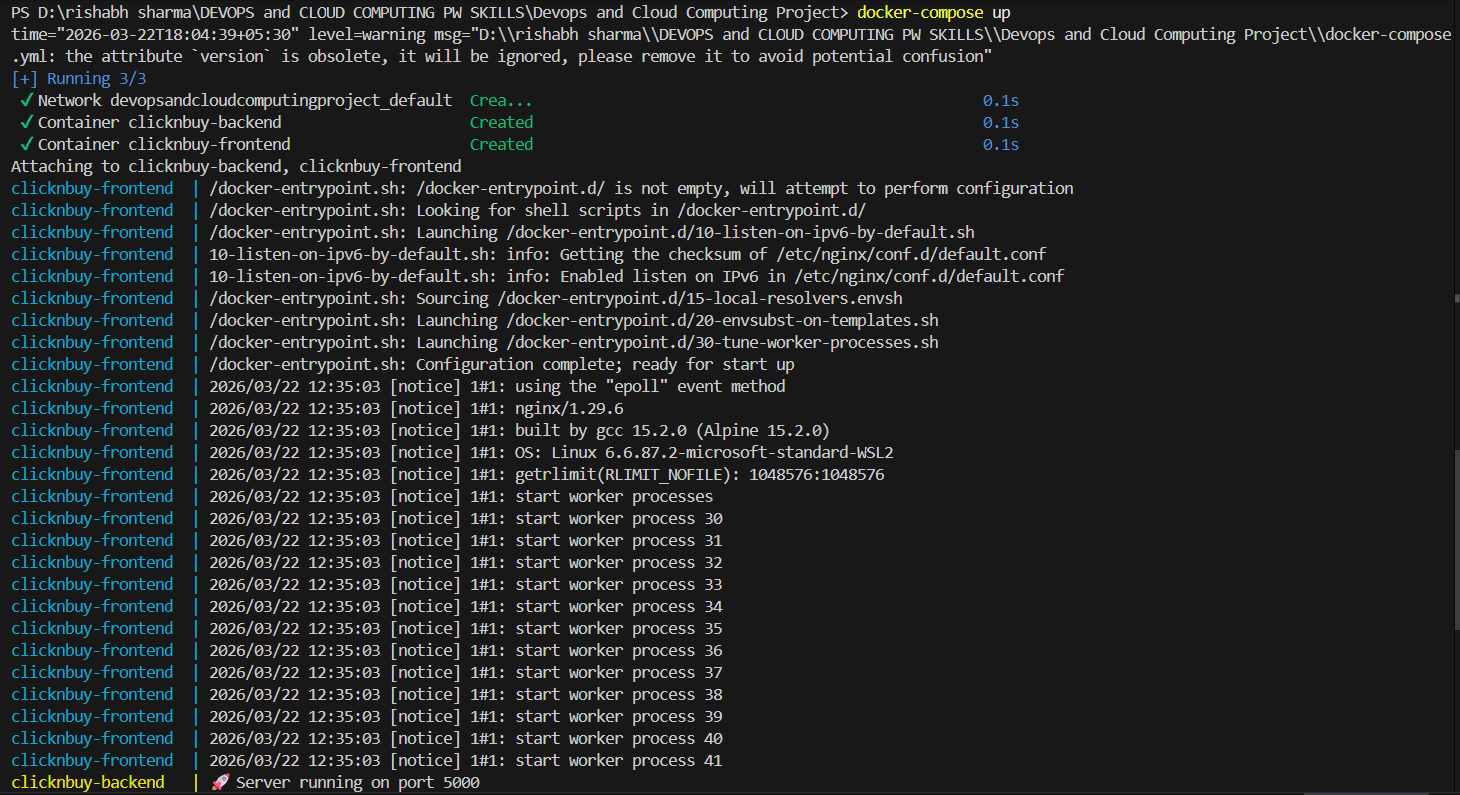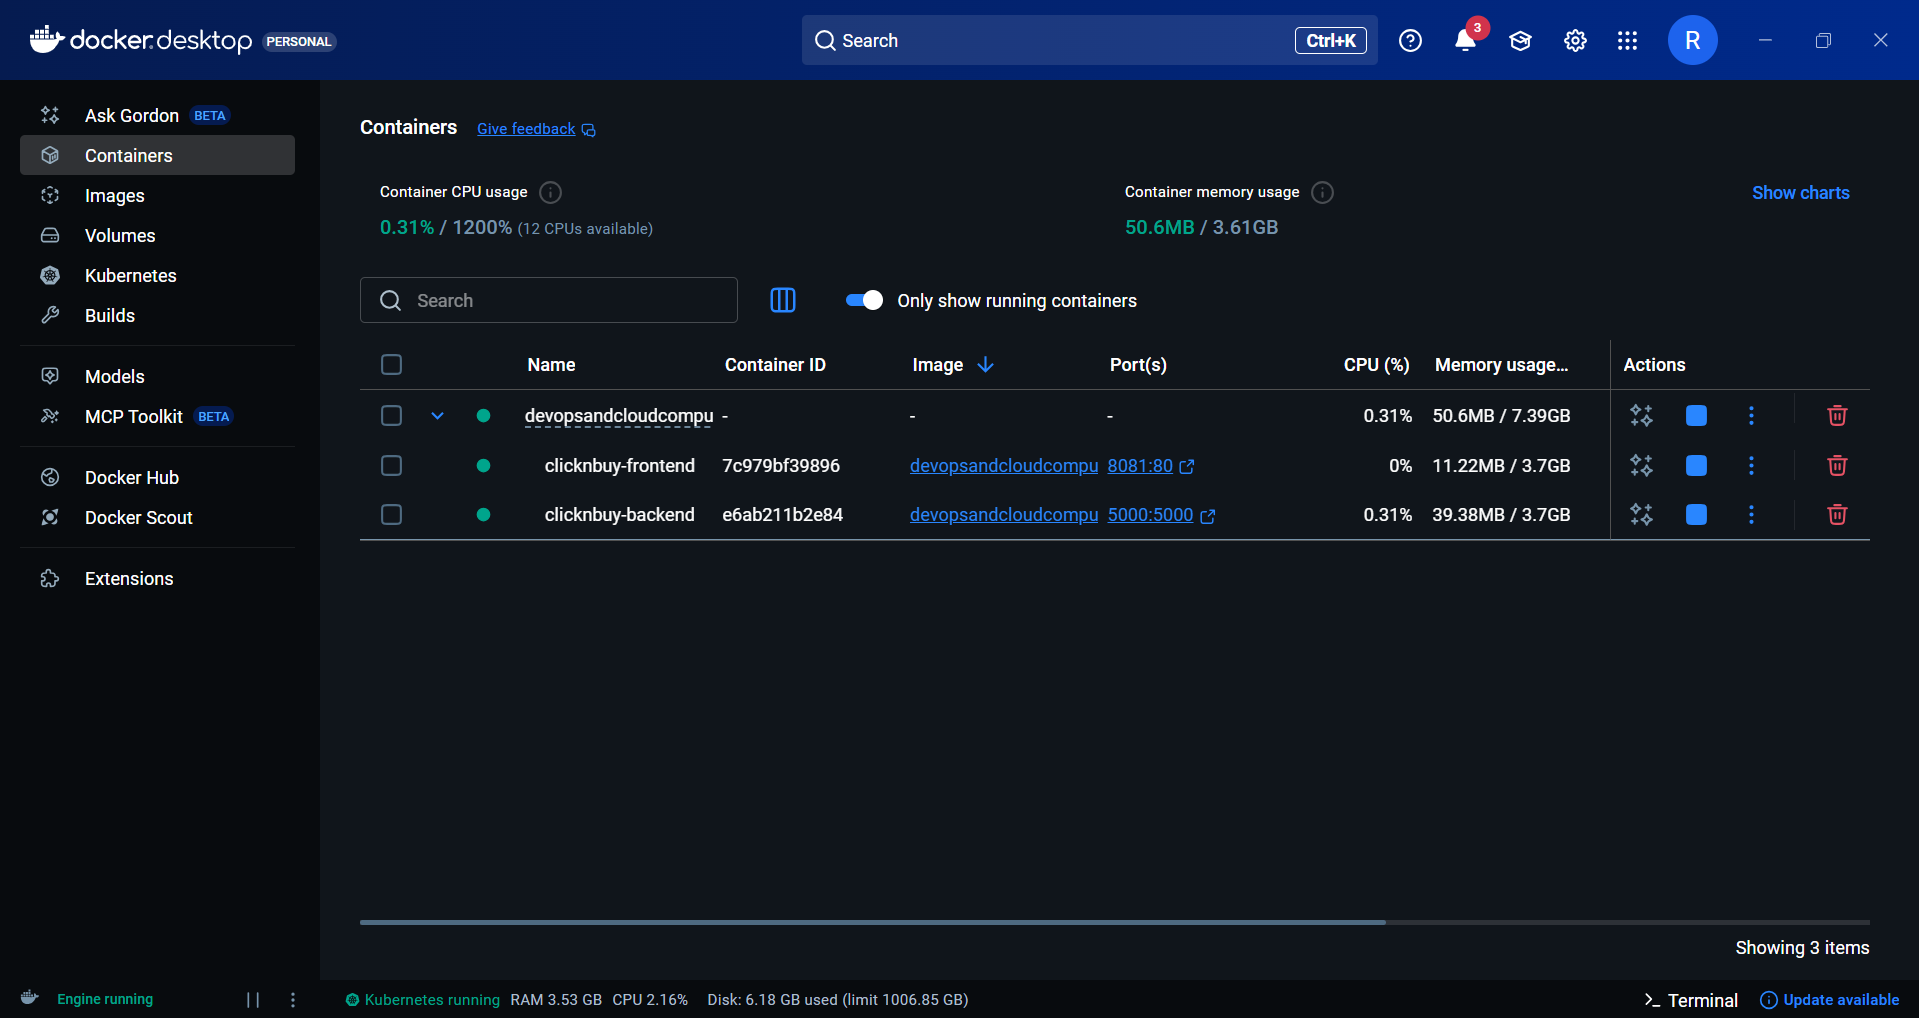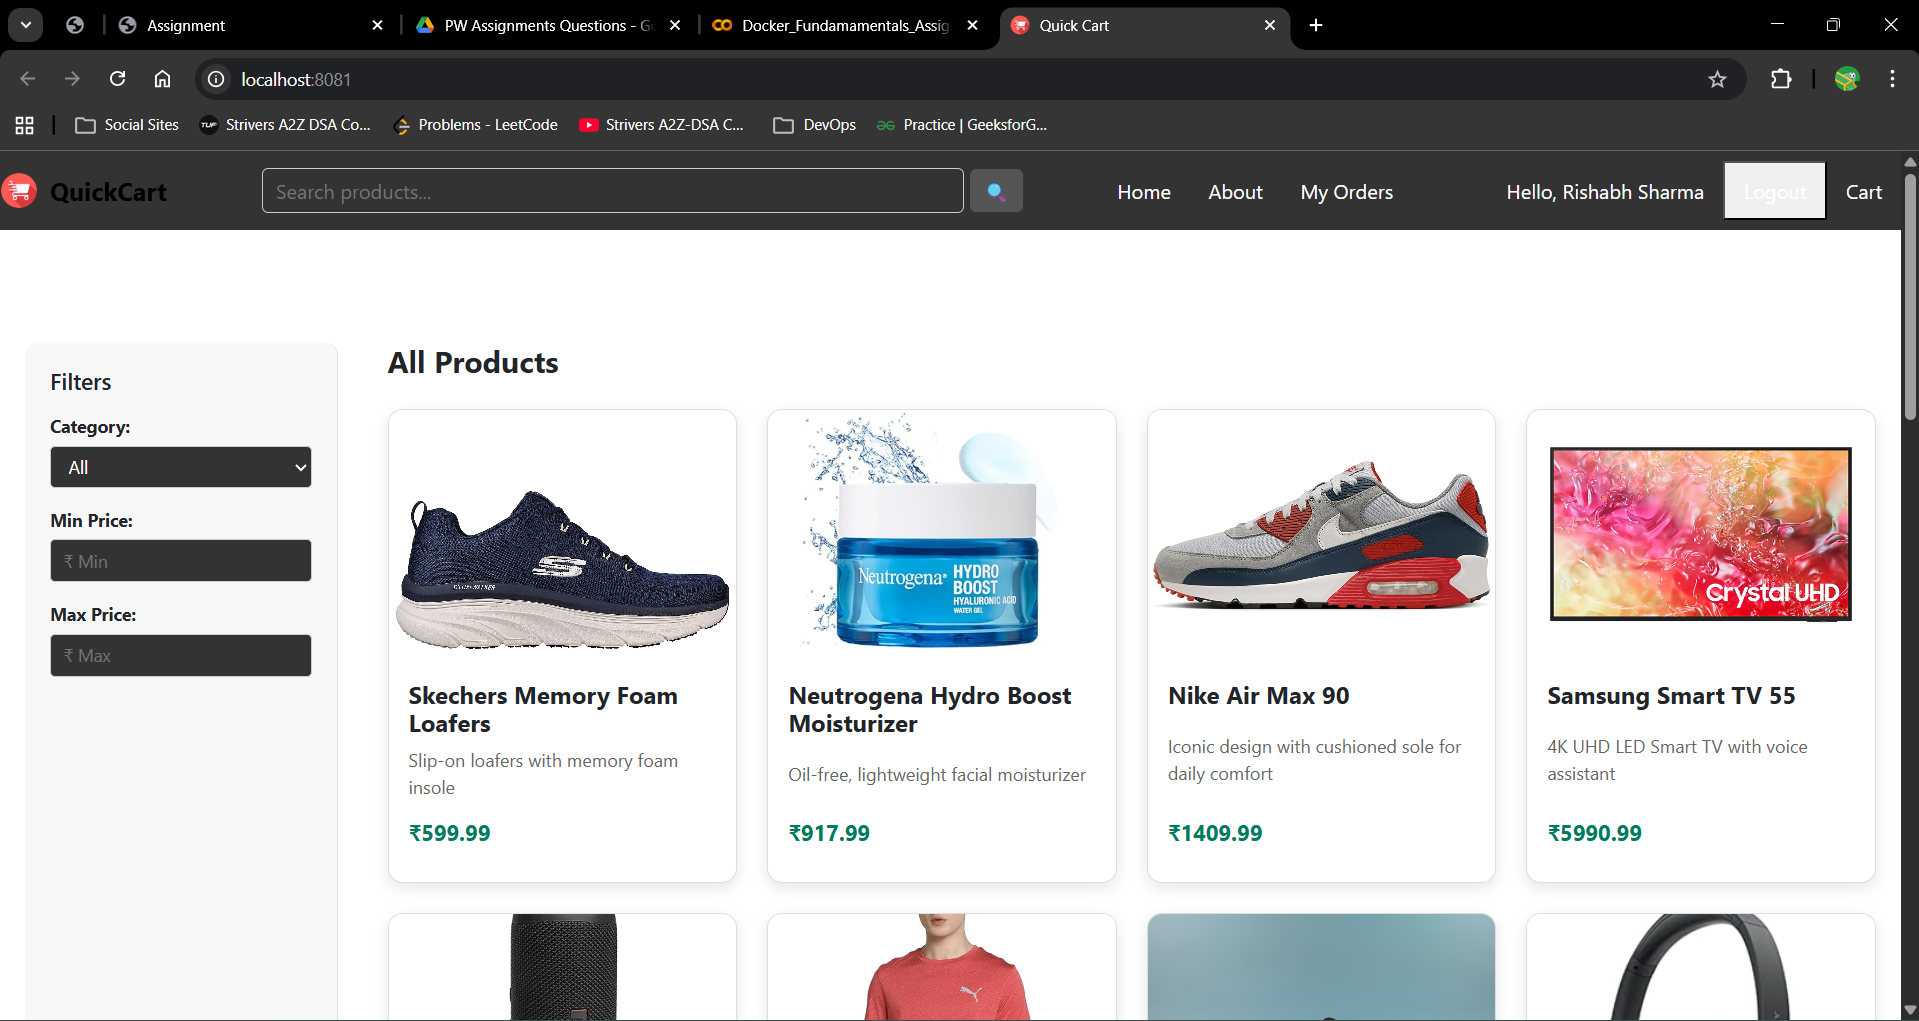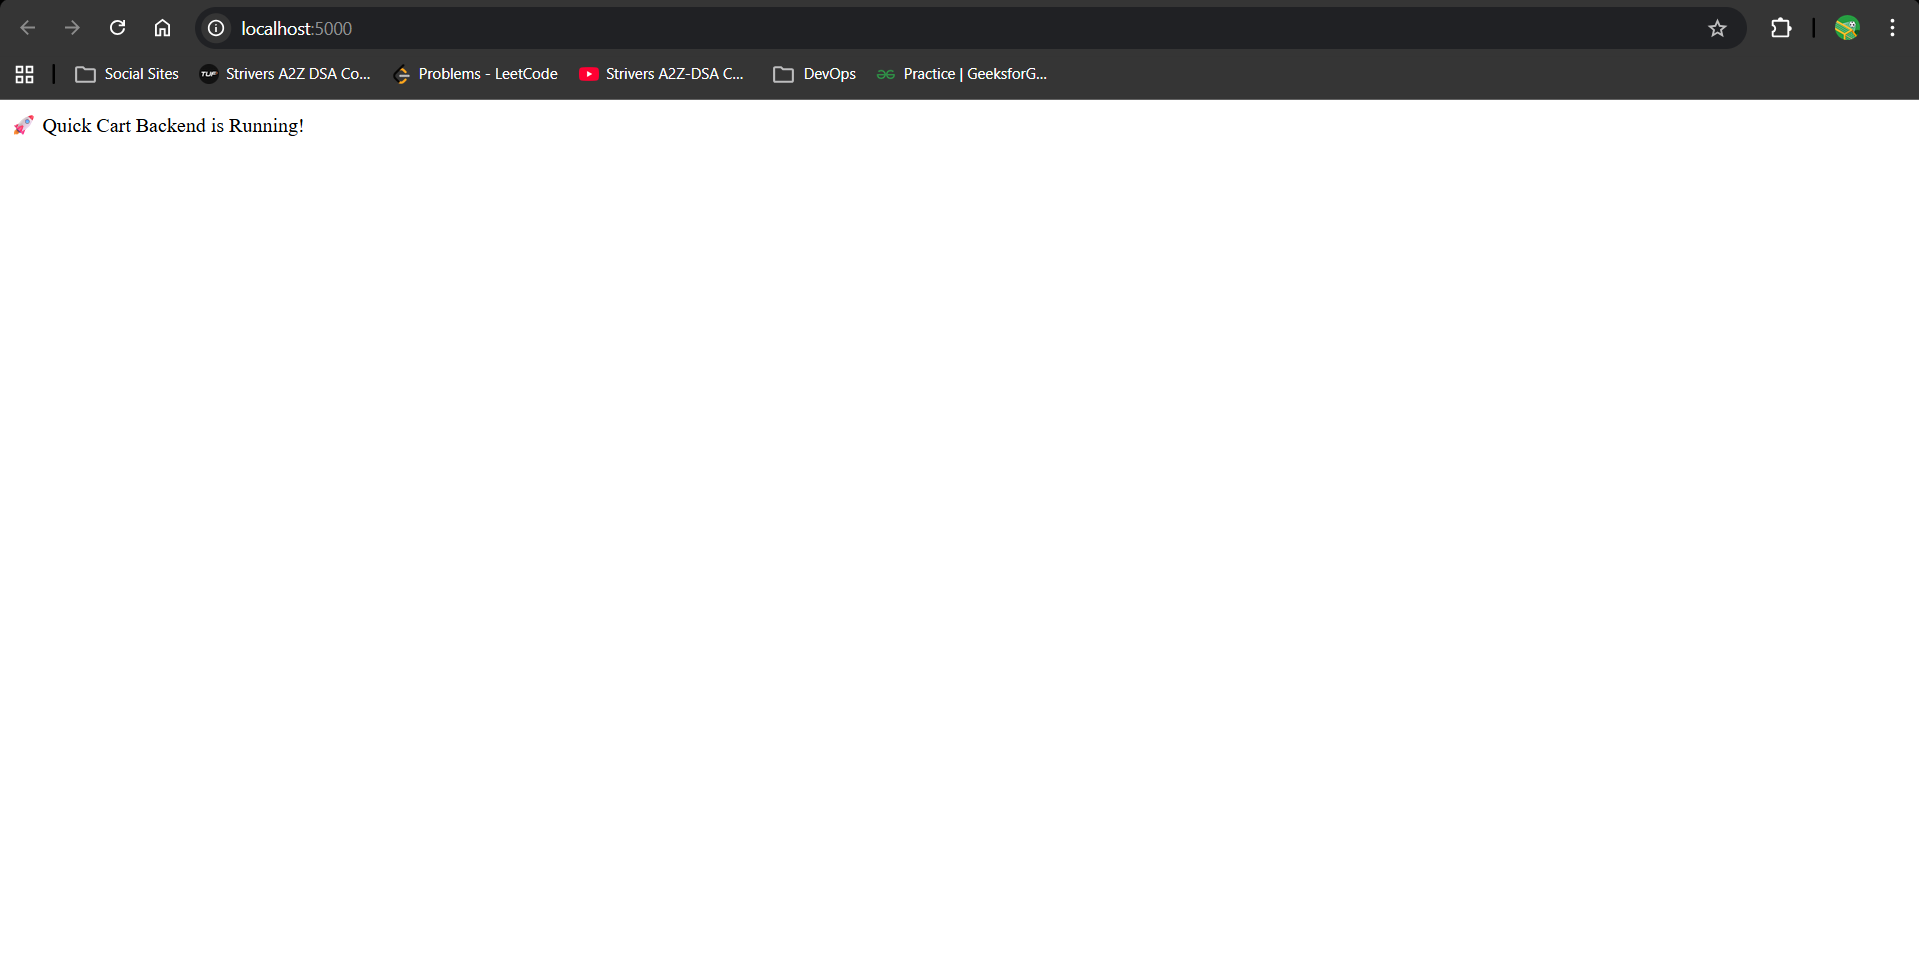